# Comparative SICR Modelling of Protest Demobilisation

**France 2023 (Pension Reform) vs Iran 2022 (Mahsa Amini)**

This notebook implements and calibrates the SICR (Susceptible–Informed–Committed–Retired) compartmental model
for protest dynamics. The model was originally proposed by Alsulami et al. (2022) in
[*Dynamical modelling of street protests using the Yellow Vest Movement and Khabarovsk as case studies*](https://doi.org/10.1038/s41598-022-23917-z),
and extended with state-repression feedback by Petrovskii et al. (2025) in
[*Understanding street protests: from a mathematical model to protest management*](https://doi.org/10.1371/journal.pone.0319837).

The core idea is that protest participation spreads through **social contagion**, analogous to epidemic models:
individuals "catch" the idea to protest through face-to-face interactions, shared emotions, social networks,
and media. We fit the model to two contrasting case studies using **differential evolution** and compare the
resulting parameter regimes to understand how repression intensity and social contagion shape protest trajectories.

**Research question:** *How do state responses to protest differ between the French pension protest in 2023 and
the 2022 Iranian protests, and how do these responses affect protest demobilization?*


## 1. Setup & Data Loading

We load two datasets representing contrasting protest contexts:

- **France 2023** — Weekly protest turnout estimates (midpoint of CGT union and Ministry of Interior counts)
  during the pension reform strikes. The movement saw repeated Saturday mobilisations over several months
  ([Rouxel & Yon, 2023](https://doi.org/10.15173/glj.v14i2.5519)).
- **Iran 2022** — Daily cumulative arrest figures from the Mahsa Amini protests. Since direct crowd-size
  data is unavailable, we proxy active protesters via the daily *change* in arrests, scaled by a constant
  factor ([Monshipouri & Zamiri, 2023](https://doi.org/10.1111/mepo.12722)).


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from scipy.optimize import differential_evolution
import warnings
warnings.filterwarnings('ignore')

# Model functions in separate module for multiprocessing compatibility
from sicr import simulate_sicr, loss


In [28]:

# Load Data
df_fr = pd.read_csv('data/france_2023_weekly.csv')
df_fr['date'] = pd.to_datetime(df_fr['date'])
t_fr = (df_fr['date'] - df_fr['date'].min()).dt.days.values
N_fr = df_fr['mid'].values

df_ir = pd.read_csv('data/iran_2022_weekly.csv')
df_ir['Date'] = pd.to_datetime(df_ir['Date'])
t_ir = (df_ir['Date'] - df_ir['Date'].min()).dt.days.values
daily_arrests = np.maximum(0, np.diff(df_ir['Number of Individuals Arrested'].values, prepend=0))
N_ir = daily_arrests * 50.0  # Proxy scaling


## 2. The SICR Model

The population is divided into four compartments, inspired by epidemic SIR-type models
(Alsulami et al., 2022):

| Compartment | Description |
|---|---|
| **S** (Susceptible) | Individuals who may join the protest |
| **I** (Informed / New protesters) | Recently recruited, aware but not yet fully committed |
| **C** (Committed / Mature protesters) | Active, experienced protesters with group identity and solidarity |
| **R** (Retired) | Individuals who have left the movement |

The ODE system is:

$$
\frac{dS}{dt} = -S(\beta_1 I + \beta_2 C) + \gamma R
$$

$$
\frac{dI}{dt} = S(\beta_1 I + \beta_2 C) - \chi I - (\delta_{11} + \epsilon_{12} P(t))\, I
$$

$$
\frac{dC}{dt} = \chi I - C \cdot \omega(I, C, t)
$$

$$
\frac{dR}{dt} = (\delta_{11} + \epsilon_{12} P(t))\, I + C \cdot \omega - \gamma R
$$

where the crowd-size-dependent retirement rate for committed protesters is:

$$
\omega(I, C, t) = \frac{\delta_{21} + \epsilon_{22} P(t)}{1 + \left(\frac{I + C}{C_0}\right)^n}
$$

Key mechanisms:
- **Social contagion** via recruitment rates $\beta_1$ (by new protesters) and $\beta_2$ (by mature protesters)
- **Commitment deepening** at rate $\chi$ — new protesters become experienced activists
- **State repression** through $\delta_{11}$, $\delta_{21}$ (baseline exit rates) and $\epsilon_{12}$, $\epsilon_{22}$ (repression amplification on protest days)
- **Crowd solidarity** — the larger the crowd $(I + C)$ relative to threshold $C_0$, the less likely committed protesters are to leave
- **Recovery** of retired individuals back into the susceptible pool at rate $\gamma$


In [29]:
# Model code is in sicr.py — imported above.
# Key functions: simulate_sicr(y0, params, t_span, protest_days, t_eval)
#                loss(params, t_obs, N_obs, S0, protest_days)

# Quick validity check: simulate with dummy params
test_params = [1e-6, 1e-7, 0.1, 0.1, 0.1, 0.01, 50000, 4.0, 0.1, 0.1]
test_sol = simulate_sicr([1e6, 100, 50, 0], test_params, [0, 10], [0, 5])
print(f"Check Solver Status: solver status = {test_sol.status}, steps = {len(test_sol.t)}")


Sanity check: solver status = 0, steps = 179


## 3. Parameter Calibration

We calibrate the model using **differential evolution** (a global optimiser) with a log-space mean squared error loss.
Two parameters are fixed to reduce identifiability issues on short time series:

| Parameter | Value | Rationale |
|---|---|---|
| $\gamma$ (recovery rate) | 0.01 | Slow return to susceptibility |
| $n$ (nonlinearity exponent) | 4.0 | Sharp collective threshold effect |

The remaining 8 parameters ($\beta_1$, $\beta_2$, $\chi$, $\delta_{11}$, $\delta_{21}$,
$C_0$, $\epsilon_{12}$, $\epsilon_{22}$) are estimated from data.

Fitted parameters are cached to `results/fitted_params.json` to avoid re-running the expensive optimisation.


In [30]:
# Fitting — uses all CPU cores via workers=-1
import json, os
os.makedirs("results", exist_ok=True)

PARAMS_FILE = "results/fitted_params.json"

def fit_model(name, t_obs, N_obs, S0, protest_days):
    bounds = [
        (1e-7, 1e-4), (1e-9, 1e-5), (0.01, 0.5), (0.01, 0.5), (0.05, 0.5),
        (10000, S0*0.5), (0.0, 1.0), (0.0, 1.0)
    ]
    pbar = tqdm(total=200, desc=f"Fitting {name}")
    def cb(xk, convergence=None):
        pbar.update(1)
    result = differential_evolution(
        loss, bounds, args=(t_obs, N_obs, S0, protest_days),
        seed=42, popsize=10, maxiter=200, tol=1e-6,
        polish=True, workers=-1, updating="deferred", callback=cb
    )
    pbar.close()
    print(f"  {name}: loss={result.fun:.4f}, converged={result.success}")
    full_params = list(result.x)
    full_params.insert(5, 0.010)
    full_params.insert(7, 4.0)
    return full_params

# Load cached params if available, otherwise fit
if os.path.exists(PARAMS_FILE):
    print("Loading cached parameters from", PARAMS_FILE)
    with open(PARAMS_FILE) as f:
        saved = json.load(f)
    params_fr = saved["france"]
    params_ir = saved["iran"]
else:
    print("Starting calibrations...")
    params_fr = fit_model("France", t_fr, N_fr, 4000000, t_fr)
    params_ir = fit_model("Iran", t_ir, N_ir, 6000000, t_ir)
    with open(PARAMS_FILE, "w") as f:
        json.dump({"france": params_fr, "iran": params_ir}, f, indent=2)
    print("Parameters saved to", PARAMS_FILE)


Loading cached parameters from results/fitted_params.json


## 4. Results: Baseline Fit

The plots below compare observed protest activity (circles) against the fitted SICR model (line).
The y-axis uses a logarithmic scale to capture the wide dynamic range of protest sizes.


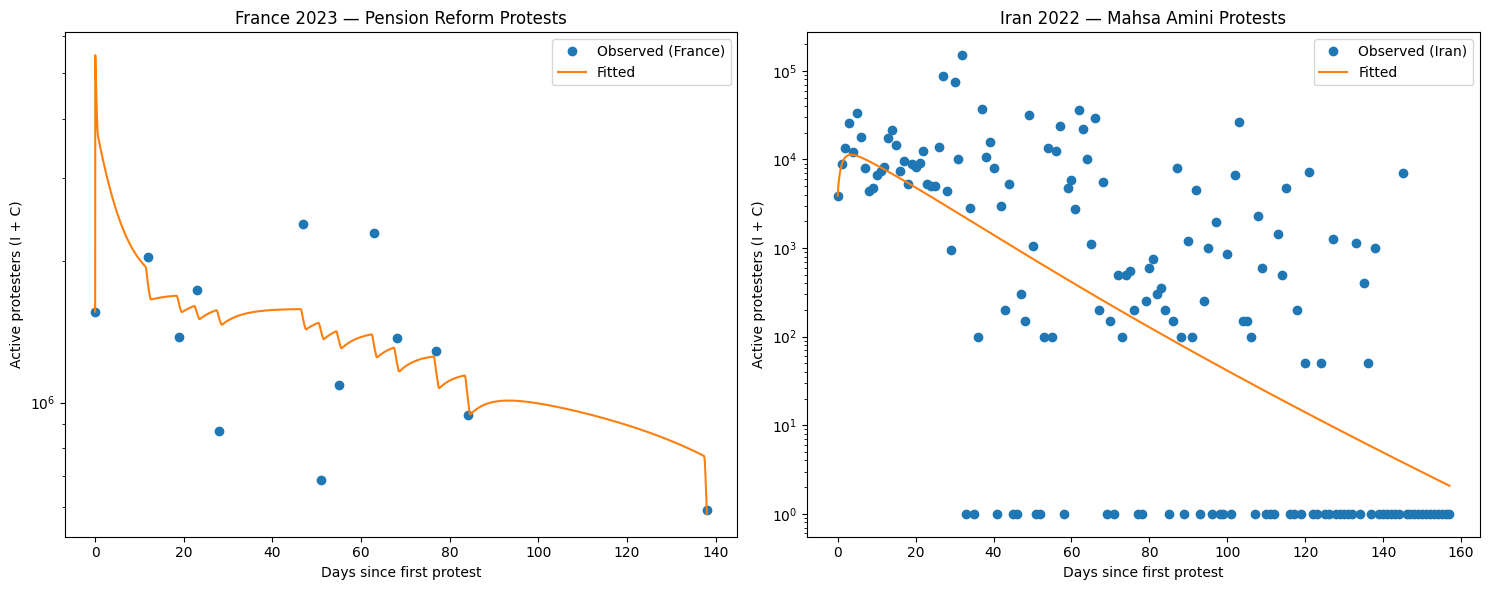

In [31]:

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

y0_fr = [4000000, max(1, N_fr[0]*0.1), max(1, N_fr[0]*0.9), 0]
sol_fr = simulate_sicr(y0_fr, params_fr, [0, t_fr[-1]], protest_days=t_fr)
ax1.plot(t_fr, np.maximum(1, N_fr), 'o', label='Observed (France)')
ax1.plot(sol_fr.t, np.maximum(1, sol_fr.y[1] + sol_fr.y[2]), label='Fitted')
ax1.set_yscale('log')
ax1.set_xlabel('Days since first protest')
ax1.set_ylabel('Active protesters (I + C)')
ax1.set_title('France 2023 — Pension Reform Protests')
ax1.legend()

y0_ir = [6000000, max(1, N_ir[0]*0.1), max(1, N_ir[0]*0.9), 0]
sol_ir = simulate_sicr(y0_ir, params_ir, [0, t_ir[-1]], protest_days=t_ir)
ax2.plot(t_ir, np.maximum(1, N_ir), 'o', label='Observed (Iran)')
ax2.plot(sol_ir.t, np.maximum(1, sol_ir.y[1] + sol_ir.y[2]), label='Fitted')
ax2.set_yscale('log')
ax2.set_xlabel('Days since first protest')
ax2.set_ylabel('Active protesters (I + C)')
ax2.set_title('Iran 2022 — Mahsa Amini Protests')
ax2.legend()

plt.tight_layout()
plt.show()


## 5. Discussion

The SICR model captures the broad demobilisation dynamics in both cases:

- **France 2023** shows a slower, more sustained pattern of protest with periodic mobilisation spikes
  aligned to national strike days. Once institutional and legal constraints tightened and moderate
  union strategies hit a ceiling, mobilisation shifted towards more autonomous and youth-driven street
  actions (Rouxel & Yon, 2023).
- **Iran 2022** exhibits a sharp initial peak followed by rapid decay, consistent with intense state
  repression — including mass arrests, internet shutdowns, and surveillance — driving quick retirement
  from protest activity (Monshipouri & Zamiri, 2023).

These contrasting trajectories illustrate how the balance between social contagion
($\beta_1$, $\beta_2$) and repression intensity ($\delta_{21}$, $\epsilon_{22}$) governs whether a
protest movement sustains or collapses. The nonlinear crowd-solidarity term further explains
why large initial turnout can sustain a movement: once $(I+C)$ exceeds the threshold $C_0$,
the retirement rate for committed protesters drops sharply.

### References

1. Alsulami, A., Glukhov, A., Shishlenin, M., & Petrovskii, S. (2022). Dynamical modelling of street protests using the Yellow Vest Movement and Khabarovsk as case studies. *Scientific Reports*, 12, 20447. [doi:10.1038/s41598-022-23917-z](https://doi.org/10.1038/s41598-022-23917-z)
2. Petrovskii, S., Shishlenin, M., & Glukhov, A. (2025). Understanding street protests: from a mathematical model to protest management. *PLoS ONE*, 20(4), e0319837. [doi:10.1371/journal.pone.0319837](https://doi.org/10.1371/journal.pone.0319837)
3. Monshipouri, M., & Zamiri, R. (2023). Woman, Life, Freedom, One Year Later: Will the Iran Protests Succeed? *Middle East Policy*, 30(4), 10–25. [doi:10.1111/mepo.12722](https://doi.org/10.1111/mepo.12722)
4. Rouxel, P., & Yon, K. (2023). From Pension Reform to Regime Crisis: The Social Movement of 2023 in France. *Global Labour Journal*, 14(2). [doi:10.15173/glj.v14i2.5519](https://doi.org/10.15173/glj.v14i2.5519)
